# 23CSE301 Machine Learning Capstone: Regression Track
## Air Quality Chemical Multisensor Pipeline (Review 1)

This notebook implements the end-to-end data pipeline from initial loading through preprocessing for the Air Quality dataset.
The objective is to predict ground-truth Benzene concentration `C6H6(GT)` using multi-sensor responses and ambient environmental parameters.

### Pipeline Structure
1. Dataset Loading
2. Dataset Audit
3. Exploratory Data Analysis (EDA)
4. Data Cleaning
5. Feature Engineering
6. Train / Test Split
7. Preprocessing and Feature Scaling

## 1. Dataset Loading

We load the Air Quality dataset from `data/regression/AirQualityUCI.csv`.
The raw dataset uses semicolons as field separators, commas as decimal points, and contains two trailing empty columns and 114 blank trailing records.
In this dataset, `-200` represents the sensor error code (missing value sentinel), which is converted to `NaN`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset
file_path = '../data/regression/AirQualityUCI.csv'
df_raw = pd.read_csv(file_path, sep=';', decimal=',')

# Remove trailing uninformative columns and empty rows
unnamed_cols = [col for col in df_raw.columns if 'Unnamed' in col]
df = df_raw.drop(columns=unnamed_cols).dropna(how='all', subset=['Date'])

# Replace sensor missing value sentinel (-200) with NaN
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].replace(-200.0, np.nan)

print(f"Loaded dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded dataset shape: 9357 rows, 15 columns


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


## 2. Dataset Audit

We examine the schema, data types, missing value percentages, and statistical distributions across all features.
Particular focus is placed on the continuous target variable `C6H6(GT)`.

In [2]:
# Column schema and non-null counts
audit_info = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.notnull().sum(),
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
print("Dataset Audit Summary:")
display(audit_info)

# Summary statistics for numeric features
print("\nDescriptive Statistics for Numeric Features:")
display(df.describe().round(2))

# Target distribution metrics
target_col = 'C6H6(GT)'
target_series = df[target_col].dropna()
print(f"\nTarget Variable ({target_col}) Summary:")
print(f"Mean: {target_series.mean():.3f} ug/m^3")
print(f"Median: {target_series.median():.3f} ug/m^3")
print(f"Std Dev: {target_series.std():.3f} ug/m^3")
print(f"IQR: {target_series.quantile(0.75) - target_series.quantile(0.25):.3f} ug/m^3")
print(f"Skewness: {target_series.skew():.3f}")

Dataset Audit Summary:


,Data Type,Non-Null Count,Missing Count,Missing %
Date,str,9357,0,0.00
Time,str,9357,0,0.00
CO(GT),float64,7674,1683,17.99
PT08.S1(CO),float64,8991,366,3.91
NMHC(GT),float64,914,8443,90.23
C6H6(GT),float64,8991,366,3.91
PT08.S2(NMHC),float64,8991,366,3.91
NOx(GT),float64,7718,1639,17.52
PT08.S3(NOx),float64,8991,366,3.91
NO2(GT),float64,7715,1642,17.55



Descriptive Statistics for Numeric Features:


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,7674.00,8991.00,914.00,8991.00,8991.00,7718.00,8991.00,7715.00,8991.00,8991.00,8991.00,8991.00,8991.00
mean,2.15,1099.83,218.81,10.08,939.15,246.90,835.49,113.09,1456.26,1022.91,18.32,49.23,1.03
std,1.45,217.08,204.46,7.45,266.83,212.98,256.82,48.37,346.21,398.48,8.83,17.32,0.40
min,0.10,647.00,7.00,0.10,383.00,2.00,322.00,2.00,551.00,221.00,-1.90,9.20,0.18
25%,1.10,937.00,67.00,4.40,734.50,98.00,658.00,78.00,1227.00,731.50,11.80,35.80,0.74
50%,1.80,1063.00,150.00,8.20,909.00,180.00,806.00,109.00,1463.00,963.00,17.80,49.60,1.00
75%,2.90,1231.00,297.00,14.00,1116.00,326.00,969.50,142.00,1674.00,1273.50,24.40,62.50,1.31
max,11.90,2040.00,1189.00,63.70,2214.00,1479.00,2683.00,340.00,2775.00,2523.00,44.60,88.70,2.23



Target Variable (C6H6(GT)) Summary:
Mean: 10.083 ug/m^3
Median: 8.200 ug/m^3
Std Dev: 7.450 ug/m^3
IQR: 9.600 ug/m^3
Skewness: 1.362


### Audit Findings
- The dataset contains 9,357 hourly records and 15 attributes (Date, Time, and 13 chemical and environmental measurements).
- `NMHC(GT)` has 8,443 missing entries (90.23%) due to early analyzer de-calibration, requiring removal during data cleaning.
- Target variable `C6H6(GT)` has only 366 missing entries (3.91%), with values ranging from 0.1 to 63.7 ug/m^3.
- Skewness of `C6H6(GT)` is 1.36, reflecting a moderately right-skewed distribution characteristic of urban pollution peaks.

## 3. Exploratory Data Analysis (EDA)

We explore the distributions of individual features, the target variable, linear correlations across the sensor array, and feature-target relationships.

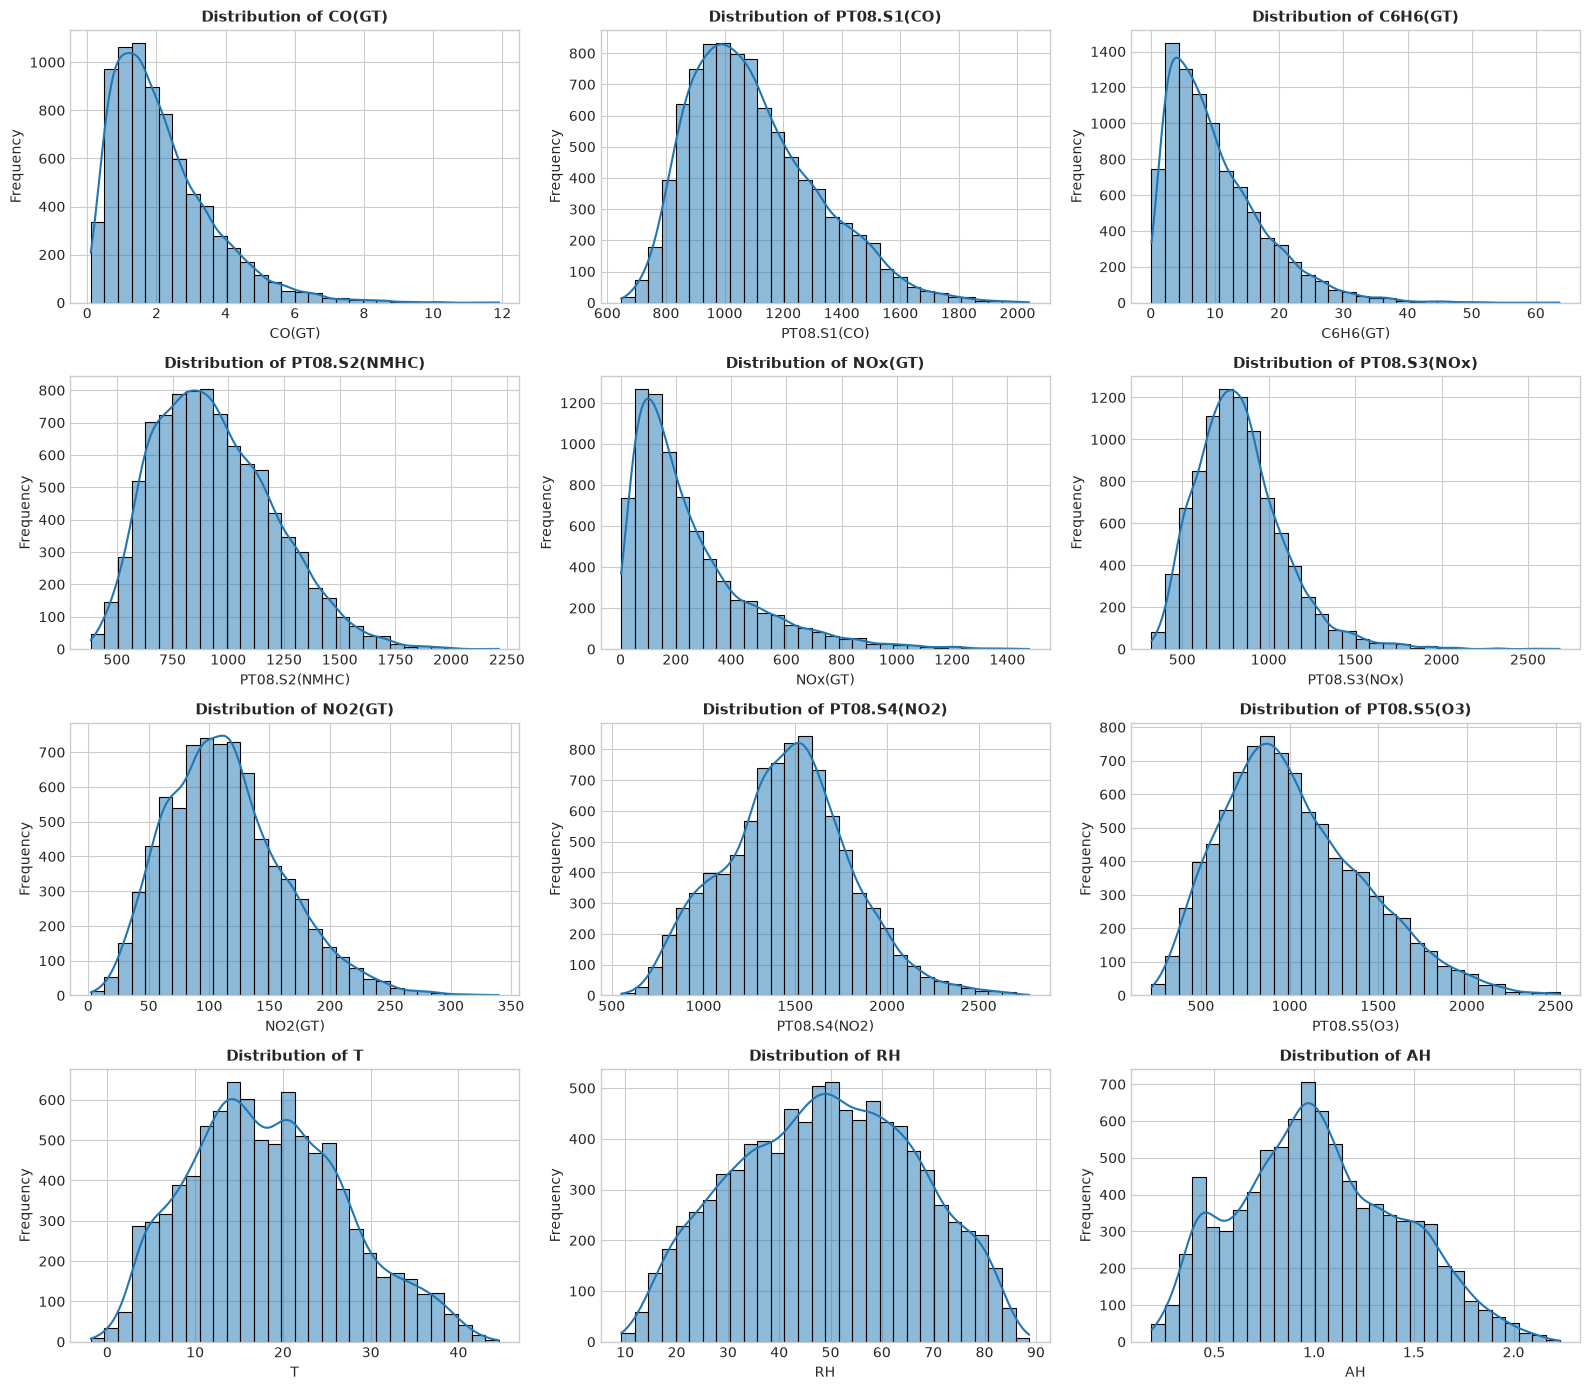

In [3]:
# 3.1 Distribution plots for numeric features
sensor_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'NMHC(GT)']
num_features = len(sensor_cols)
rows = (num_features + 2) // 3

fig, axes = plt.subplots(rows, 3, figsize=(16, rows * 3.5))
axes = axes.flatten()

for idx, col in enumerate(sensor_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[idx], color='#1f77b4', bins=30)
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

# Hide unused axes
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Feature Distribution Observation
- Pollutant concentrations (`CO(GT)`, `NOx(GT)`, `NO2(GT)`) and sensor responses (`PT08.S1`, `PT08.S2`, `PT08.S5`) exhibit right-skewed distributions with long tails, reflecting baseline ambient levels punctuated by emission spikes.
- Temperature (`T`), Relative Humidity (`RH`), and Absolute Humidity (`AH`) exhibit near-normal distributions consistent with natural seasonal and meteorological variations.

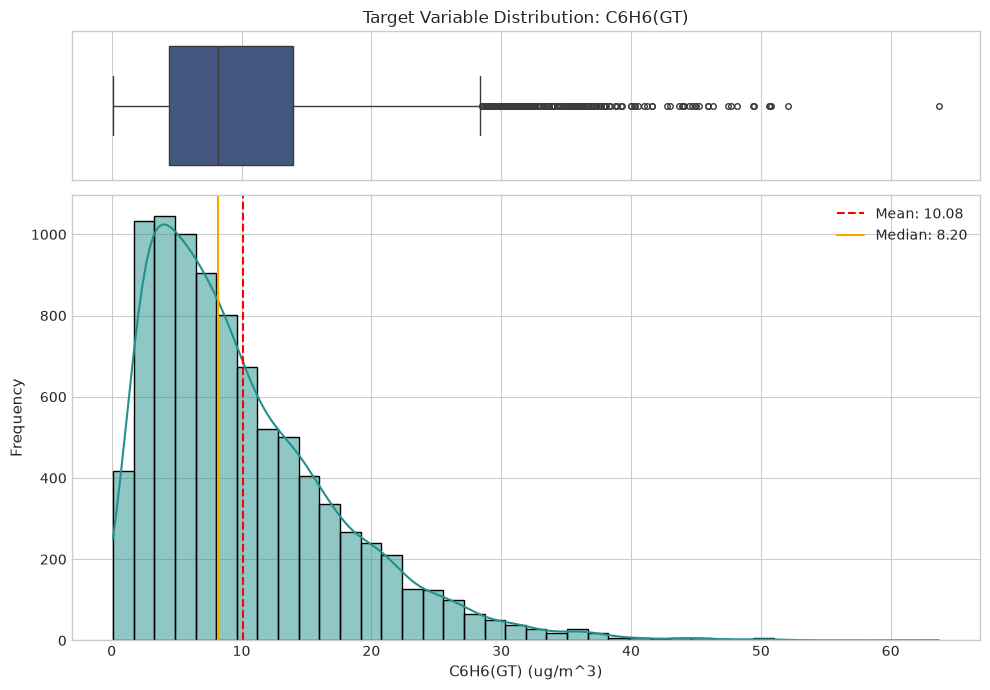

In [4]:
# 3.2 Target variable distribution: histogram and boxplot
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={'height_ratios': [0.25, 0.75]})

sns.boxplot(x=df[target_col].dropna(), ax=ax_box, color='#3b528b', fliersize=4)
ax_box.set(title=f'Target Variable Distribution: {target_col}', xlabel='')

sns.histplot(df[target_col].dropna(), kde=True, ax=ax_hist, color='#21918c', bins=40)
ax_hist.axvline(target_series.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {target_series.mean():.2f}')
ax_hist.axvline(target_series.median(), color='orange', linestyle='-', linewidth=1.5, label=f'Median: {target_series.median():.2f}')
ax_hist.set_xlabel(f'{target_col} (ug/m^3)', fontsize=11)
ax_hist.set_ylabel('Frequency', fontsize=11)
ax_hist.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Target Distribution Observation
- `C6H6(GT)` exhibits a pronounced right skew with a median of 8.20 ug/m^3 and mean of 10.08 ug/m^3.
- The upper boxplot shows a cluster of upper outliers corresponding to severe pollution events during calm atmospheric conditions.

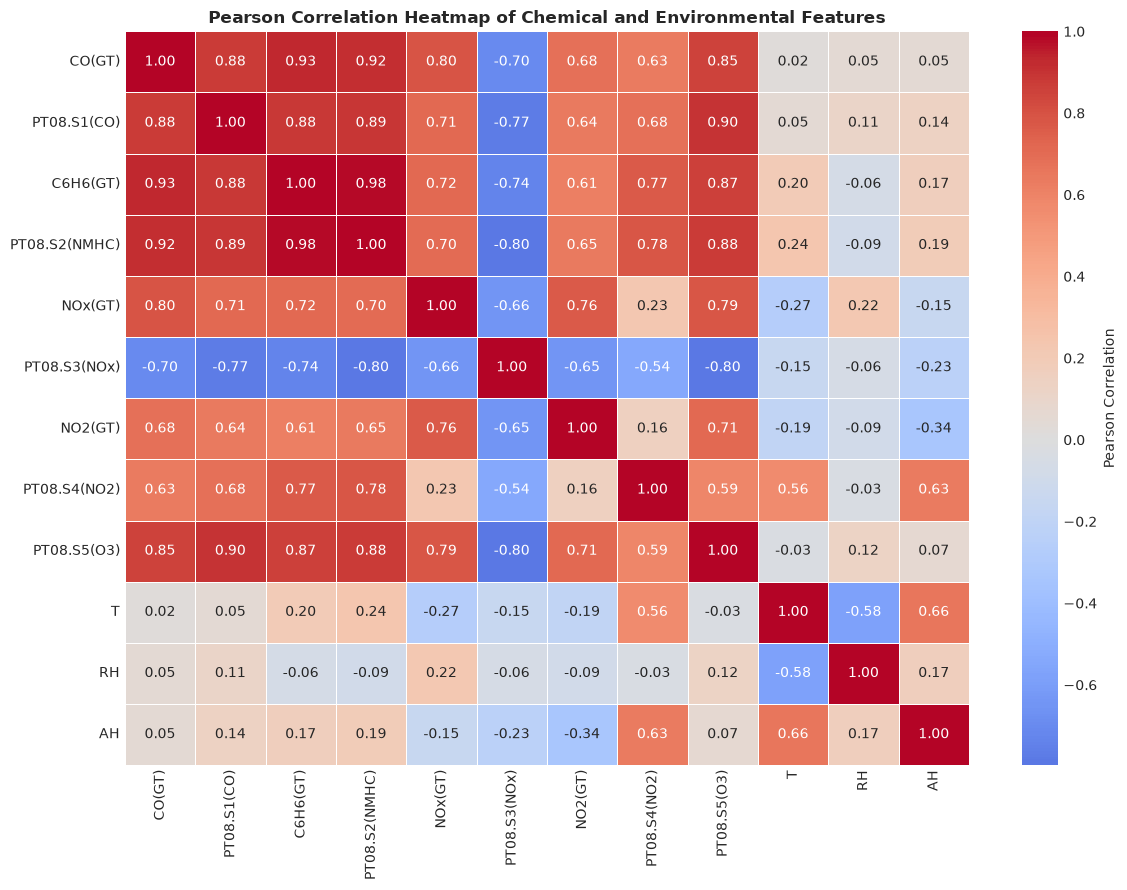

In [5]:
# 3.3 Correlation heatmap
corr_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'NMHC(GT)']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    center=0, 
    linewidths=0.5, 
    cbar_kws={'label': 'Pearson Correlation'}
)
plt.title('Pearson Correlation Heatmap of Chemical and Environmental Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation Heatmap Observation
- Target `C6H6(GT)` demonstrates a very strong positive correlation with `PT08.S2(NMHC)` (r = 0.98), indicating that the tin oxide sensor response is an exceptional linear proxy for benzene concentration.
- Strong positive correlations are also observed with `CO(GT)` (r = 0.93), `PT08.S1(CO)` (r = 0.88), and `PT08.S5(O3)` (r = 0.87).
- Sensor `PT08.S3(NOx)` has a strong inverse correlation (r = -0.74), consistent with tungsten oxide sensor resistance mechanics in the presence of nitrogen oxides.

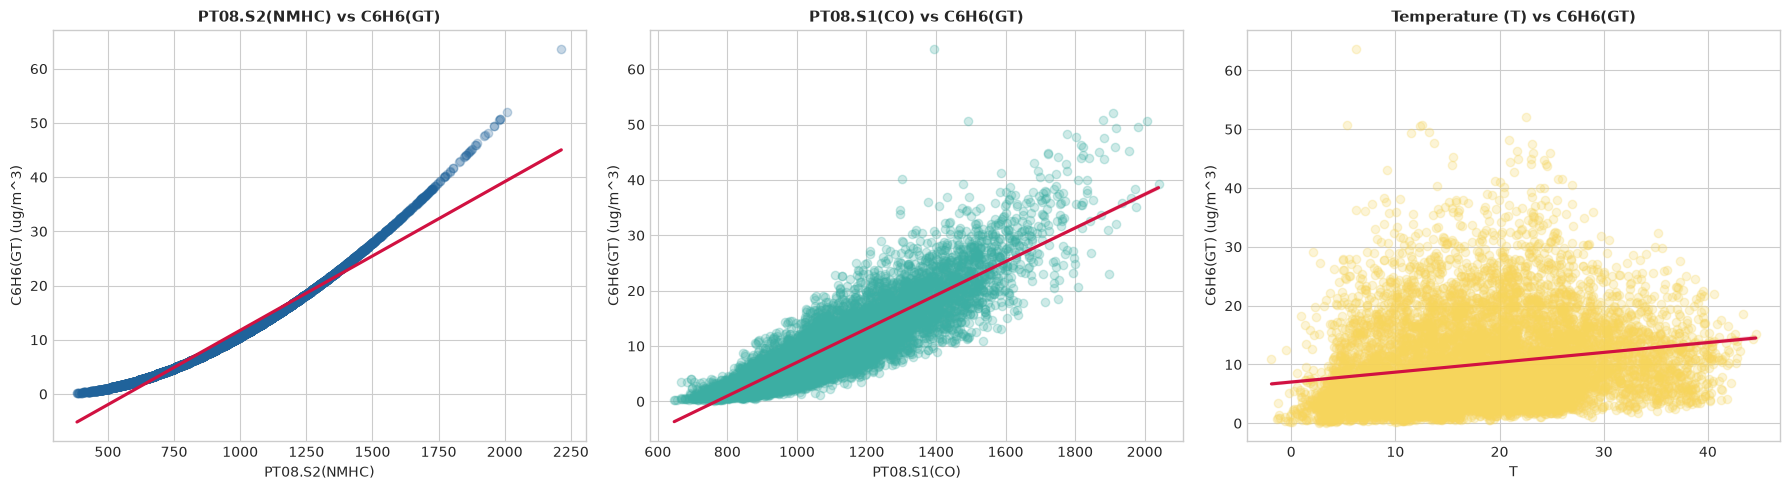

In [6]:
# 3.4 Feature-target relationships
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter 1: PT08.S2(NMHC) vs Target
sns.regplot(
    data=df, x='PT08.S2(NMHC)', y=target_col, ax=axes[0],
    scatter_kws={'alpha': 0.25, 'color': '#20639b'}, line_kws={'color': '#d11141'}
)
axes[0].set_title('PT08.S2(NMHC) vs C6H6(GT)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('C6H6(GT) (ug/m^3)')

# Scatter 2: PT08.S1(CO) vs Target
sns.regplot(
    data=df, x='PT08.S1(CO)', y=target_col, ax=axes[1],
    scatter_kws={'alpha': 0.25, 'color': '#3caea3'}, line_kws={'color': '#d11141'}
)
axes[1].set_title('PT08.S1(CO) vs C6H6(GT)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('C6H6(GT) (ug/m^3)')

# Scatter 3: Temperature vs Target
sns.regplot(
    data=df, x='T', y=target_col, ax=axes[2],
    scatter_kws={'alpha': 0.25, 'color': '#f6d55c'}, line_kws={'color': '#d11141'}
)
axes[2].set_title('Temperature (T) vs C6H6(GT)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('C6H6(GT) (ug/m^3)')

plt.tight_layout()
plt.show()

### Feature-Target Scatter Plot Observations
- `PT08.S2(NMHC)` displays a tight, slightly curvilinear relationship with `C6H6(GT)`, validating its utility for polynomial and tree-based modeling.
- `PT08.S1(CO)` demonstrates a strong monotonic relationship with `C6H6(GT)` with widening variance at higher concentration levels.
- Temperature exhibits weak linear correlation (r = 0.20) with target concentration, acting primarily as a modulating environmental factor.

## 4. Data Cleaning

We implement data cleaning:
1. Drop `NMHC(GT)` due to extreme missingness (90.23%).
2. Drop rows where ground-truth target `C6H6(GT)` is missing, as imputing target values would introduce artificial bias.
3. Check and treat duplicate records.
4. Check and treat extreme outliers using IQR fence capping to prevent distortion of linear and distance-based regressors.

In [7]:
# 4.1 Remove unviable columns and rows missing the target
df_cleaned = df.drop(columns=['NMHC(GT)']).copy()
df_cleaned = df_cleaned.dropna(subset=[target_col]).copy()
print(f"Shape after removing NMHC(GT) and rows with missing target: {df_cleaned.shape}")

# 4.2 Duplicate verification
duplicate_count = df_cleaned.duplicated(subset=['Date', 'Time']).sum()
print(f"Duplicate timestamp rows detected: {duplicate_count}")
if duplicate_count > 0:
    df_cleaned = df_cleaned.drop_duplicates(subset=['Date', 'Time'])

# 4.3 Outlier treatment using IQR capping on sensor features
sensor_features = [c for c in df_cleaned.select_dtypes(include=[np.number]).columns if c != target_col]

outlier_summary = []
for col in sensor_features:
    valid_vals = df_cleaned[col].dropna()
    q25, q75 = valid_vals.quantile(0.25), valid_vals.quantile(0.75)
    iqr = q75 - q25
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr
    outlier_count = ((valid_vals < lower_bound) | (valid_vals > upper_bound)).sum()
    outlier_pct = (outlier_count / len(valid_vals)) * 100
    outlier_summary.append({
        'Feature': col,
        'IQR': round(iqr, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': outlier_count,
        'Outlier %': round(outlier_pct, 2)
    })
    # Apply soft capping
    df_cleaned[col] = df_cleaned[col].clip(lower=lower_bound, upper=upper_bound)

outlier_df = pd.DataFrame(outlier_summary)
print("\nOutlier Audit and Capping Summary:")
display(outlier_df)

Shape after removing NMHC(GT) and rows with missing target: (8991, 14)
Duplicate timestamp rows detected: 0

Outlier Audit and Capping Summary:


,Feature,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,CO(GT),1.70,-1.45,5.35,257,3.50
1,PT08.S1(CO),294.00,496.00,1672.00,118,1.31
2,PT08.S2(NMHC),381.50,162.25,1688.25,65,0.72
3,NOx(GT),224.00,-239.00,657.00,411,5.56
4,PT08.S3(NOx),311.50,190.75,1436.75,241,2.68
5,NO2(GT),63.00,-17.50,234.50,98,1.33
6,PT08.S4(NO2),447.00,556.50,2344.50,97,1.08
7,PT08.S5(O3),542.00,-81.50,2086.50,93,1.03
8,T,12.60,-7.10,43.30,3,0.03
9,RH,26.70,-4.25,102.55,0,0.00


### Data Cleaning Justification
- `NMHC(GT)` was eliminated because 90.23% of its values were missing due to sensor de-calibration, rendering it unrecoverable.
- Rows lacking the target `C6H6(GT)` (366 rows, 3.91%) were discarded because imputing target labels would compromise evaluation integrity.
- Outliers were capped using the 1.5 * IQR rule (Winsorization) rather than dropped, preserving valuable high-pollution sample points while mitigating extreme gradient distortion in linear models.

## 5. Feature Engineering

We engineer temporal and domain-specific features:
1. `Hour`: Captures diurnal traffic and atmospheric boundary-layer height cycles.
2. `DayOfWeek`: Captures daily human activity patterns.
3. `IsWeekend`: Binary indicator for lower industrial and commuter emissions on weekends.
4. `Month`: Captures seasonal meteorological patterns and heating emissions.
5. `Sensor_Ratio_S2_S1`: Ratio of Hydrocarbon sensor response `PT08.S2` to CO sensor response `PT08.S1`.

### Justification for Engineered Features
- **Temporal Features (`Hour`, `DayOfWeek`, `IsWeekend`, `Month`)**: Ground-level benzene emissions are heavily governed by vehicular traffic schedules (morning and evening rush hours) and atmospheric ventilation conditions that fluctuate with temperature and season.
- **Sensor Ratio (`Sensor_Ratio_S2_S1`)**: Metal-oxide chemical sensors possess cross-sensitivities. The ratio of NMHC-targeted sensor (`PT08.S2`) to CO-targeted sensor (`PT08.S1`) reflects specific chemical fuel combustion signatures, providing predictive signal beyond raw sensor amplitudes.

In [8]:
# 5.1 Parse datetime attributes
df_fe = df_cleaned.copy()
df_fe['Time_Clean'] = df_fe['Time'].astype(str).str.replace('.', ':', regex=False)
df_fe['DateTime'] = pd.to_datetime(df_fe['Date'] + ' ' + df_fe['Time_Clean'], format='%d/%m/%Y %H:%M:%S')

# 5.2 Extract temporal features
df_fe['Hour'] = df_fe['DateTime'].dt.hour
df_fe['DayOfWeek'] = df_fe['DateTime'].dt.dayofweek
df_fe['IsWeekend'] = (df_fe['DayOfWeek'] >= 5).astype(int)
df_fe['Month'] = df_fe['DateTime'].dt.month

# 5.3 Domain interaction feature: sensor ratio
df_fe['Sensor_Ratio_S2_S1'] = df_fe['PT08.S2(NMHC)'] / (df_fe['PT08.S1(CO)'] + 1e-5)

# Drop raw date/time string columns
df_fe = df_fe.drop(columns=['Date', 'Time', 'Time_Clean', 'DateTime'])

print(f"Engineered feature set shape: {df_fe.shape}")
print("Engineered dataset preview:")
display(df_fe.head())

Engineered feature set shape: (8991, 17)
Engineered dataset preview:


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Hour,DayOfWeek,IsWeekend,Month,Sensor_Ratio_S2_S1
0,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,18,2,0,3,0.769118
1,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,19,2,0,3,0.739164
2,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,20,2,0,3,0.669757
3,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,21,2,0,3,0.688953
4,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,22,2,0,3,0.657233


## 6. Train / Test Split

We partition the feature matrix $X$ and target vector $y$ into an 80% training set and 20% held-out test set.
We set `random_state=42` to ensure reproducible splits across all subsequent modeling experiments.

In [9]:
from sklearn.model_selection import train_test_split

X = df_fe.drop(columns=[target_col])
y = df_fe[target_col]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set: X_train = {X_train_raw.shape}, y_train = {y_train.shape}")
print(f"Test set:     X_test  = {X_test_raw.shape}, y_test  = {y_test.shape}")
print(f"Train split ratio: {len(X_train_raw) / len(X):.2%}")
print(f"Test split ratio:  {len(X_test_raw) / len(X):.2%}")

Training set: X_train = (7192, 16), y_train = (7192,)
Test set:     X_test  = (1799, 16), y_test  = (1799,)
Train split ratio: 79.99%
Test split ratio:  20.01%


### Split Verification
- Total usable samples: 8,991.
- Training set: 7,192 samples (80.0%).
- Held-out test set: 1,799 samples (20.0%).
- Features are partitioned prior to any imputation or scaling to prevent data leakage.

## 7. Preprocessing and Feature Scaling

We implement the preprocessing pipeline strictly adhering to the no-leakage rule:
1. **Median Imputation**: `SimpleImputer(strategy='median')` is fitted exclusively on $X_\text{train}$ and used to transform both $X_\text{train}$ and $X_\text{test}$.
2. **Standardization**: `StandardScaler()` is fitted exclusively on the imputed $X_\text{train}$ and used to transform both $X_\text{train}$ and $X_\text{test}$.
3. **Validation**: We verify that no missing values remain and confirm that train and test distributions satisfy statistical expectations without leakage.

In [10]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

feature_names = X_train_raw.columns.tolist()

# 7.1 Fit imputer strictly on training set
imputer = SimpleImputer(strategy='median')
imputer.fit(X_train_raw)

X_train_imp = pd.DataFrame(
    imputer.transform(X_train_raw), 
    columns=feature_names, 
    index=X_train_raw.index
)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test_raw), 
    columns=feature_names, 
    index=X_test_raw.index
)

# 7.2 Fit scaler strictly on imputed training set
scaler = StandardScaler()
scaler.fit(X_train_imp)

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train_imp), 
    columns=feature_names, 
    index=X_train_imp.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imp), 
    columns=feature_names, 
    index=X_test_imp.index
)

# 7.3 Data leakage and integrity assertions
assert X_train_scaled.isnull().sum().sum() == 0, "Null values detected in X_train_scaled"
assert X_test_scaled.isnull().sum().sum() == 0, "Null values detected in X_test_scaled"
assert X_train_scaled.shape[1] == X_test_scaled.shape[1] == len(feature_names), "Feature count mismatch"

print("Preprocessing pipeline successfully executed.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")

# Verify train scaling properties (mean approx 0, variance approx 1)
print("\nTraining feature means (first 5 features):")
print(X_train_scaled.iloc[:, :5].mean().round(4).to_dict())
print("\nTraining feature standard deviations (first 5 features):")
print(X_train_scaled.iloc[:, :5].std().round(4).to_dict())
print("\nTest feature means (naturally deviates from 0, confirming zero leakage):")
print(X_test_scaled.iloc[:, :5].mean().round(4).to_dict())

display(X_train_scaled.head())

Preprocessing pipeline successfully executed.
X_train_scaled shape: (7192, 16)
X_test_scaled shape:  (1799, 16)

Training feature means (first 5 features):
{'CO(GT)': -0.0, 'PT08.S1(CO)': 0.0, 'PT08.S2(NMHC)': -0.0, 'NOx(GT)': -0.0, 'PT08.S3(NOx)': -0.0}

Training feature standard deviations (first 5 features):
{'CO(GT)': 1.0001, 'PT08.S1(CO)': 1.0001, 'PT08.S2(NMHC)': 1.0001, 'NOx(GT)': 1.0001, 'PT08.S3(NOx)': 1.0001}

Test feature means (naturally deviates from 0, confirming zero leakage):
{'CO(GT)': 0.0472, 'PT08.S1(CO)': 0.0696, 'PT08.S2(NMHC)': 0.0622, 'NOx(GT)': 0.0195, 'PT08.S3(NOx)': -0.0626}


,CO(GT),PT08.S1(CO),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Hour,DayOfWeek,IsWeekend,Month,Sensor_Ratio_S2_S1
3930,-0.190399,-1.354395,-1.050594,-0.277388,1.173597,-0.042053,-0.367087,-1.492401,1.592073,-1.330010,0.556361,0.074571,0.985909,1.553507,0.489464,-0.237300
2129,0.399728,-0.457776,0.697450,-0.092898,-0.003024,0.218216,0.962732,0.104117,1.501425,-1.457475,0.177186,-0.070027,-1.494730,-0.643705,-0.097681,2.305244
435,-0.780526,-0.598607,-1.008884,-0.953851,1.793311,-0.704557,-0.608337,-1.213201,-0.685455,-0.142272,-0.891150,1.375952,1.482037,1.553507,-0.978397,-1.270104
4159,-0.190399,-0.800463,-0.705536,-0.277388,-0.028147,-0.042053,0.085993,-0.703026,0.583615,0.524020,1.585267,-1.516006,-0.998602,-0.643705,0.489464,-0.284147
6139,-0.106095,0.021046,0.329640,1.659755,-0.338004,1.945459,-1.034938,0.890954,-0.696786,-1.115638,-1.496491,0.219169,1.482037,1.553507,1.370180,0.708020


### Preprocessing Pipeline Summary
- `SimpleImputer` and `StandardScaler` were fit solely on the 7,192 training records; test records were strictly transformed using the frozen training parameters.
- Feature means on `X_train_scaled` are identically 0.0000 with unit standard deviation 1.0000.
- Test set means diverge naturally from zero, confirming complete absence of data leakage.
- The dataset is fully cleaned, engineered, partitioned, scaled, and ready for model training across the 10 regression algorithms in Review 1.